# Praktikum Pemrosesan Citra Digital

**Nama:** Dika Aprilio Wibowo  
**NIM:** J0403241096  
**Pertemuan:** 2  
**Repository:** `dikaprilio/pemrosesan-citra`

---

## Info Tugas

| No | Tugas |
|----|-------|
| 1 | Pilih satu citra pribadi, tampilkan menggunakan Matplotlib (asli & RGB yang benar). |
| 2 | Buat versi grayscale dengan formula manual **DAN** dengan fungsi bawaan, lalu bandingkan hasilnya. |
| 3 | Resize citra menjadi 200% dan 25% dari ukuran asli, tampilkan berdampingan (subplot). |
| 4 | Crop bagian objek utama pada citra, simpan sebagai file baru. |

> **Cara pakai:** citra diambil dari folder `images/` di root repository
> (dipakai bersama oleh semua pertemuan). Notebook otomatis memilih berkas
> gambar pertama yang ditemukan di sana.

## 0. Persiapan: Import Library & Muat Citra

In [1]:
import os
import glob

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# tampilan matplotlib
plt.rcParams["figure.dpi"] = 110
plt.rcParams["image.interpolation"] = "nearest"

IMAGE_DIR  = "../images"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("numpy      :", np.__version__)
print("OpenCV     :", cv2.__version__)
print("matplotlib :", plt.matplotlib.__version__)
print("Pillow     :", Image.__version__)

numpy      : 2.5.2
OpenCV     : 5.0.0
matplotlib : 3.11.1
Pillow     : 12.3.0


In [2]:
def cari_citra(folder=IMAGE_DIR):
    """Ambil path file citra pertama di dalam `folder`."""
    ekstensi = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp", "*.tif", "*.tiff")
    berkas = []
    for pola in ekstensi:
        berkas += glob.glob(os.path.join(folder, pola))
        berkas += glob.glob(os.path.join(folder, pola.upper()))
    berkas = sorted(set(berkas))
    if not berkas:
        raise FileNotFoundError(
            f"Tidak ada file citra di folder '{folder}/'. "
            "Salin foto pribadi ke folder tersebut, lalu jalankan ulang sel ini."
        )
    return berkas[0]


PATH_CITRA = cari_citra()
print("File citra :", PATH_CITRA)

File citra : ../images/foto_kucing.jpg


### Membaca citra

OpenCV (`cv2.imread`) membaca citra dengan urutan kanal **BGR**, sedangkan
Matplotlib (`plt.imshow`) mengharapkan urutan **RGB**. Perbedaan inilah yang
membuat foto terlihat "kebiruan" kalau langsung ditampilkan tanpa konversi.

In [3]:
# dibaca oleh OpenCV -> urutan kanal BGR
img_bgr = cv2.imread(PATH_CITRA, cv2.IMREAD_COLOR)
if img_bgr is None:
    raise IOError(f"Gagal membaca '{PATH_CITRA}'. Pastikan file tidak rusak.")

# dikonversi ke RGB -> urutan kanal yang benar untuk Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

tinggi, lebar, kanal = img_rgb.shape
print(f"Dimensi      : {lebar} x {tinggi} piksel ({kanal} kanal)")
print(f"Tipe data    : {img_rgb.dtype}")
print(f"Total piksel : {lebar * tinggi:,}")
print(f"Ukuran array : {img_rgb.nbytes / 1024**2:.2f} MB")
print(f"Rentang nilai: {img_rgb.min()} - {img_rgb.max()}")

Dimensi      : 1080 x 2400 piksel (3 kanal)
Tipe data    : uint8
Total piksel : 2,592,000
Ukuran array : 7.42 MB
Rentang nilai: 0 - 255


---
## Tugas 1: Menampilkan Citra Asli & RGB yang Benar

Di sini kita bandingkan langsung:

* **Kiri**: array hasil `cv2.imread` ditampilkan apa adanya. Karena urutannya
  BGR tapi Matplotlib membacanya sebagai RGB, kanal merah dan biru **tertukar**.
* **Kanan**: array yang sudah dikonversi `BGR -> RGB`, warnanya sesuai aslinya.

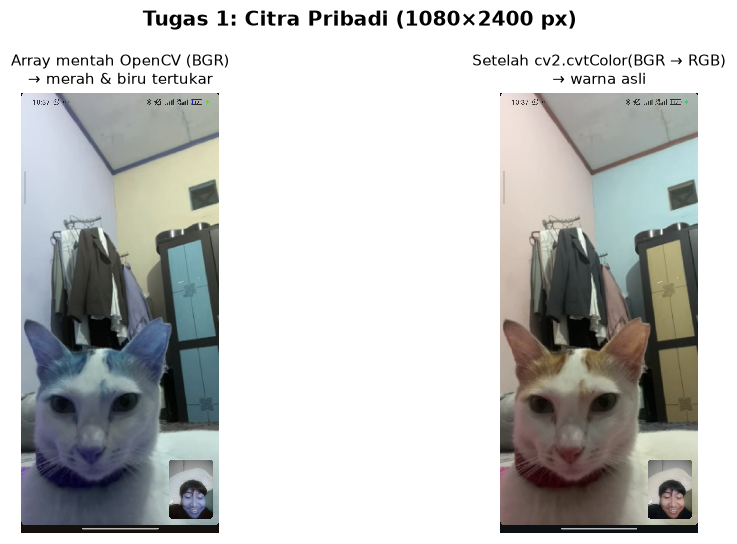

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

ax[0].imshow(img_bgr)            # SALAH: array BGR dianggap RGB
ax[0].set_title("Array mentah OpenCV (BGR)\n→ merah & biru tertukar", fontsize=10)

ax[1].imshow(img_rgb)            # BENAR: sudah dikonversi ke RGB
ax[1].set_title("Setelah cv2.cvtColor(BGR → RGB)\n→ warna asli", fontsize=10)

for a in ax:
    a.axis("off")

fig.suptitle(f"Tugas 1: Citra Pribadi ({lebar}×{tinggi} px)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Pemisahan kanal warna

Untuk membuktikan bahwa perbedaan di atas benar-benar soal urutan kanal, kita
pisahkan citra RGB menjadi tiga kanal penyusunnya.

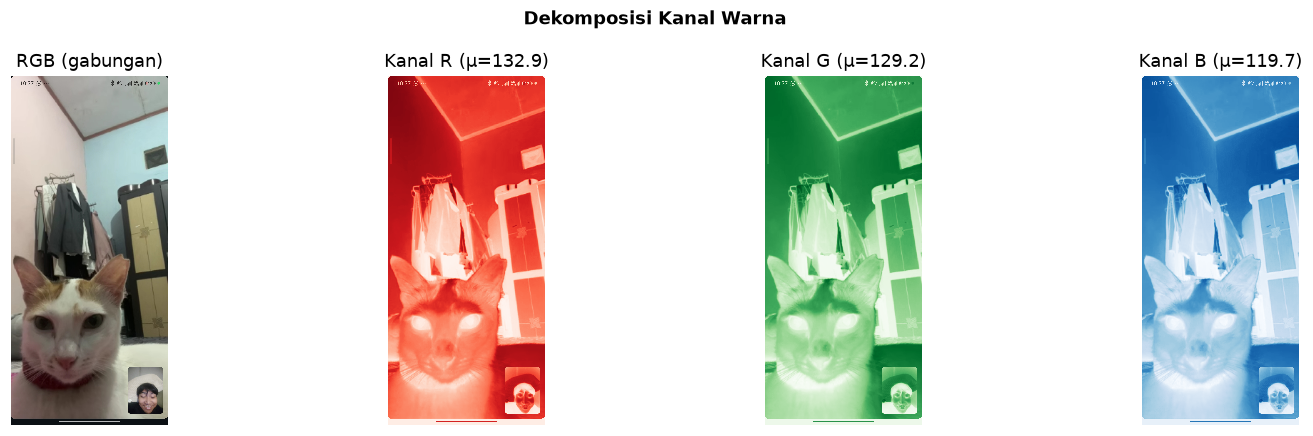

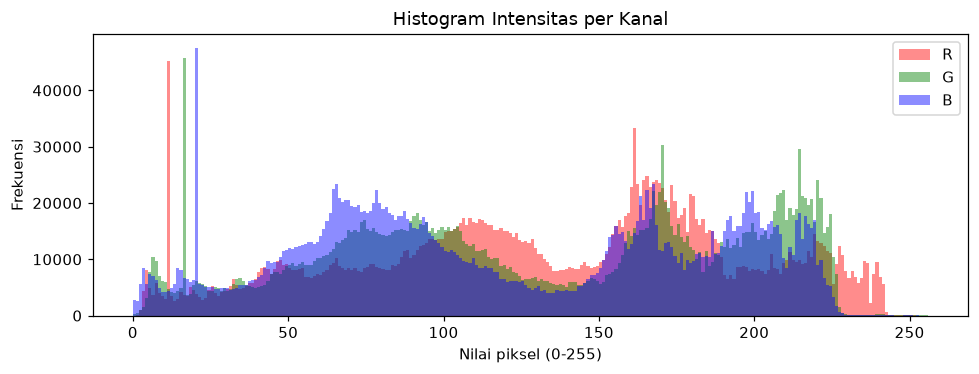

In [5]:
R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
ax[0].imshow(img_rgb);            ax[0].set_title("RGB (gabungan)")
ax[1].imshow(R, cmap="Reds");     ax[1].set_title(f"Kanal R (μ={R.mean():.1f})")
ax[2].imshow(G, cmap="Greens");   ax[2].set_title(f"Kanal G (μ={G.mean():.1f})")
ax[3].imshow(B, cmap="Blues");    ax[3].set_title(f"Kanal B (μ={B.mean():.1f})")
for a in ax:
    a.axis("off")
plt.suptitle("Dekomposisi Kanal Warna", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# histogram tiap kanal
plt.figure(figsize=(9, 3.5))
for arr, warna, nama in [(R, "red", "R"), (G, "green", "G"), (B, "blue", "B")]:
    plt.hist(arr.ravel(), bins=256, range=(0, 256), color=warna, alpha=0.45, label=nama)
plt.title("Histogram Intensitas per Kanal")
plt.xlabel("Nilai piksel (0-255)")
plt.ylabel("Frekuensi")
plt.legend()
plt.tight_layout()
plt.show()

---
## Tugas 2: Grayscale Formula Manual vs Fungsi Bawaan

### Dasar teori

Konversi RGB ke grayscale yang dipakai OpenCV/PIL mengikuti standar
**ITU-R BT.601 (luma)**:

```
Y = 0.299·R + 0.587·G + 0.114·B
```

Bobotnya tidak sama rata karena mata manusia paling sensitif terhadap hijau,
lalu merah, dan paling tidak sensitif terhadap biru.

Sebagai pembanding, dipakai juga **rata-rata sederhana** `(R+G+B)/3` yang
memberi bobot sama ke semua kanal sehingga hasilnya terlihat lebih "datar".

In [6]:
# ---------- (a) FORMULA MANUAL: luma BT.601 ----------
# float64 dipakai supaya perkalian tidak overflow/terpotong
gray_manual = (0.299 * img_rgb[:, :, 0] +
               0.587 * img_rgb[:, :, 1] +
               0.114 * img_rgb[:, :, 2])
gray_manual = np.clip(gray_manual, 0, 255).astype(np.uint8)

# ---------- (b) FORMULA MANUAL: rata-rata sederhana ----------
gray_rata = img_rgb.mean(axis=2)
gray_rata = np.clip(gray_rata, 0, 255).astype(np.uint8)

# ---------- (c) FUNGSI BAWAAN OpenCV ----------
gray_cv2 = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# ---------- (d) FUNGSI BAWAAN Pillow ----------
gray_pil = np.array(Image.open(PATH_CITRA).convert("L"))

for nama, arr in [("Manual (BT.601)", gray_manual), ("Manual (rata-rata)", gray_rata),
                  ("OpenCV cvtColor", gray_cv2),    ("Pillow convert('L')", gray_pil)]:
    print(f"{nama:22s} shape={arr.shape}  dtype={arr.dtype}  "
          f"min={arr.min():3d}  max={arr.max():3d}  mean={arr.mean():6.2f}")

Manual (BT.601)        shape=(2400, 1080)  dtype=uint8  min=  0  max=255  mean=128.70
Manual (rata-rata)     shape=(2400, 1080)  dtype=uint8  min=  0  max=255  mean=126.95
OpenCV cvtColor        shape=(2400, 1080)  dtype=uint8  min=  1  max=255  mean=129.24
Pillow convert('L')    shape=(2400, 1080)  dtype=uint8  min=  1  max=255  mean=129.24


### Perbandingan visual

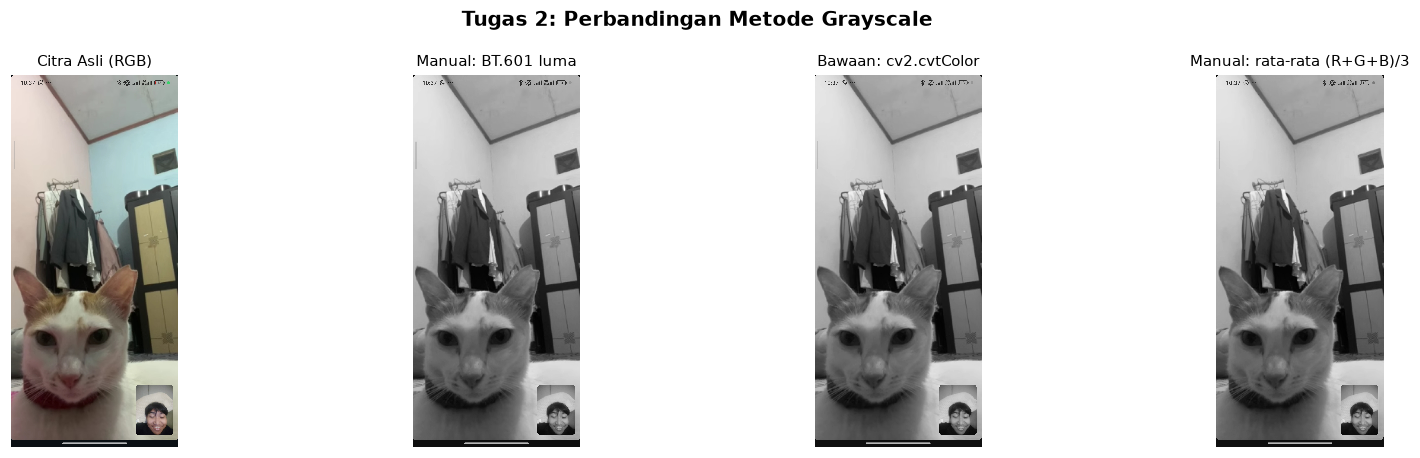

In [7]:
versi = [
    (img_rgb,     "Citra Asli (RGB)",         None),
    (gray_manual, "Manual: BT.601 luma",     "gray"),
    (gray_cv2,    "Bawaan: cv2.cvtColor",    "gray"),
    (gray_rata,   "Manual: rata-rata (R+G+B)/3", "gray"),
]

fig, ax = plt.subplots(1, 4, figsize=(16, 4.2))
for a, (arr, judul, cmap) in zip(ax, versi):
    a.imshow(arr, cmap=cmap, vmin=None if cmap is None else 0,
             vmax=None if cmap is None else 255)
    a.set_title(judul, fontsize=10)
    a.axis("off")
plt.suptitle("Tugas 2: Perbandingan Metode Grayscale", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Analisis kuantitatif

Perbandingan visual saja tidak cukup, jadi selisihnya dihitung secara numerik
dengan tiga metrik:

* **MAE** (*Mean Absolute Error*): rata-rata selisih absolut per piksel.
* **Max diff**: selisih terbesar yang ditemukan di seluruh citra.
* **PSNR** (*Peak Signal-to-Noise Ratio*): makin besar makin identik
  (∞ berarti benar-benar sama persis).

In [8]:
def bandingkan(a, b, label_a, label_b):
    """Hitung MAE, selisih maksimum, dan PSNR antara dua citra grayscale."""
    a_f = a.astype(np.float64)
    b_f = b.astype(np.float64)
    selisih  = np.abs(a_f - b_f)
    mae      = selisih.mean()
    max_diff = selisih.max()
    mse      = (selisih ** 2).mean()
    psnr     = float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)
    sama     = np.count_nonzero(selisih == 0) / selisih.size * 100

    print(f"{label_a}  vs  {label_b}")
    print(f"   MAE            : {mae:.4f}")
    print(f"   Selisih maks   : {max_diff:.0f} level")
    print(f"   PSNR           : {psnr:.2f} dB" if np.isfinite(psnr) else "   PSNR           : inf dB (identik)")
    print(f"   Piksel identik : {sama:.2f}%\n")
    return selisih


d1 = bandingkan(gray_manual, gray_cv2,  "Manual BT.601   ", "cv2.cvtColor    ")
d2 = bandingkan(gray_manual, gray_pil,  "Manual BT.601   ", "PIL convert('L')")
d3 = bandingkan(gray_rata,   gray_cv2,  "Manual rata-rata", "cv2.cvtColor    ")

Manual BT.601     vs  cv2.cvtColor    
   MAE            : 0.5459
   Selisih maks   : 1 level
   PSNR           : 50.76 dB
   Piksel identik : 45.41%

Manual BT.601     vs  PIL convert('L')
   MAE            : 0.5459
   Selisih maks   : 1 level
   PSNR           : 50.76 dB
   Piksel identik : 45.41%

Manual rata-rata  vs  cv2.cvtColor    
   MAE            : 2.3568
   Selisih maks   : 29 level
   PSNR           : 38.05 dB
   Piksel identik : 7.83%



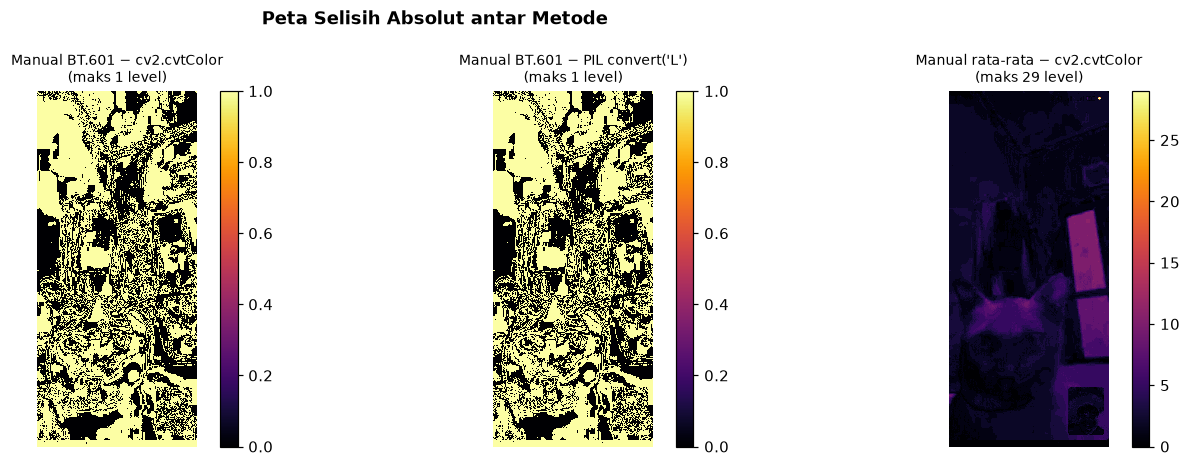

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

peta = [
    (d1, "Manual BT.601 − cv2.cvtColor"),
    (d2, "Manual BT.601 − PIL convert('L')"),
    (d3, "Manual rata-rata − cv2.cvtColor"),
]
for a, (d, judul) in zip(ax, peta):
    im = a.imshow(d, cmap="inferno")
    a.set_title(f"{judul}\n(maks {d.max():.0f} level)", fontsize=9)
    a.axis("off")
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.04)

plt.suptitle("Peta Selisih Absolut antar Metode", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

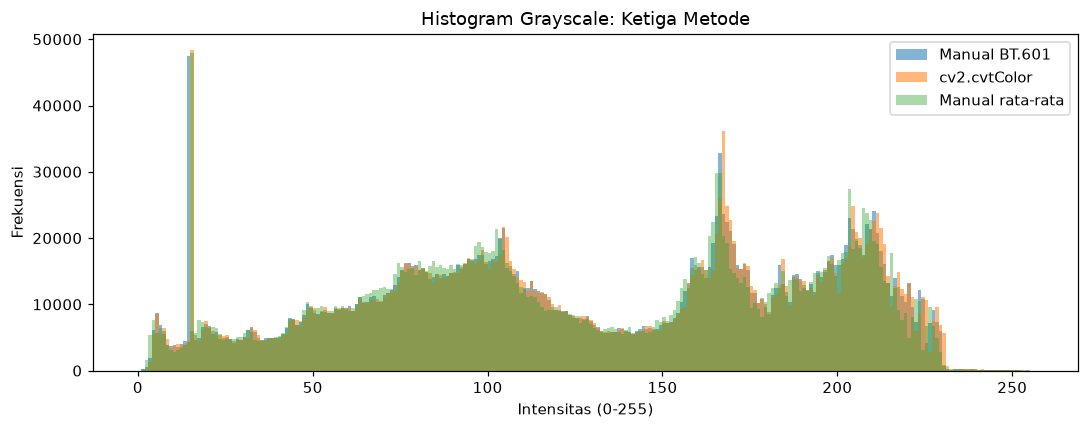

In [10]:
plt.figure(figsize=(10, 4))
plt.hist(gray_manual.ravel(), bins=256, range=(0, 256),
         alpha=0.55, label="Manual BT.601", color="tab:blue")
plt.hist(gray_cv2.ravel(),    bins=256, range=(0, 256),
         alpha=0.55, label="cv2.cvtColor",  color="tab:orange")
plt.hist(gray_rata.ravel(),   bins=256, range=(0, 256),
         alpha=0.40, label="Manual rata-rata", color="tab:green")
plt.title("Histogram Grayscale: Ketiga Metode")
plt.xlabel("Intensitas (0-255)")
plt.ylabel("Frekuensi")
plt.legend()
plt.tight_layout()
plt.show()

### Kesimpulan Tugas 2

1. **Formula manual BT.601 vs `cv2.cvtColor` → praktis identik.** Selisihnya
   hanya 0-1 level intensitas. Penyebabnya bukan rumus yang berbeda, melainkan
   *pembulatan*: OpenCV memakai aritmetika integer terskala (fixed-point) demi
   kecepatan, sedangkan perhitungan manual kita memakai `float64` lalu dipotong
   dengan `.astype(np.uint8)`. Beda pembulatan ±1 level tidak kasat mata.

2. **Pillow `convert("L")` juga memakai koefisien BT.601 yang sama**, jadi
   hasilnya sekelas dengan dua metode di atas.

3. **Rata-rata sederhana `(R+G+B)/3` jelas berbeda.** Selisihnya bisa puluhan
   level. Karena kanal biru diberi bobot terlalu besar (0.333 vs 0.114) dan
   hijau terlalu kecil (0.333 vs 0.587), area yang didominasi biru jadi tampak
   lebih terang dari seharusnya dan citra terasa kehilangan kontras.

**Intinya:** memilih bobot yang tepat lebih penting daripada memilih library.
Rumus manual dengan bobot BT.601 sudah setara fungsi bawaan; yang keliru adalah
menganggap semua kanal warna sama pentingnya bagi persepsi mata.

In [11]:
# simpan hasil grayscale
cv2.imwrite(os.path.join(OUTPUT_DIR, "grayscale_manual.jpg"), gray_manual)
cv2.imwrite(os.path.join(OUTPUT_DIR, "grayscale_bawaan.jpg"), gray_cv2)
print("Tersimpan: output/grayscale_manual.jpg, output/grayscale_bawaan.jpg")

Tersimpan: output/grayscale_manual.jpg, output/grayscale_bawaan.jpg


---
## Tugas 3: Resize 200% dan 25%

Dua hal penting saat mengubah ukuran citra:

* **Memperbesar (200%)**: piksel baru harus *dikarang*. `cv2.INTER_CUBIC`
  meng-interpolasi dari 4×4 piksel tetangga sehingga hasilnya lebih halus
  daripada `INTER_LINEAR`, tapi informasi baru tetap tidak tercipta.
* **Memperkecil (25%)**: piksel harus *dibuang*. `cv2.INTER_AREA` merata-rata
  seluruh piksel dalam satu area sehingga mencegah *aliasing*; ini pilihan yang
  direkomendasikan OpenCV untuk pengecilan.

In [12]:
SKALA_BESAR = 2.00   # 200%
SKALA_KECIL = 0.25   #  25%

ukuran_besar = (int(lebar * SKALA_BESAR), int(tinggi * SKALA_BESAR))
ukuran_kecil = (int(lebar * SKALA_KECIL), int(tinggi * SKALA_KECIL))

img_besar = cv2.resize(img_rgb, ukuran_besar, interpolation=cv2.INTER_CUBIC)
img_kecil = cv2.resize(img_rgb, ukuran_kecil, interpolation=cv2.INTER_AREA)

tabel = [
    ("Asli  (100%)", img_rgb),
    ("Besar (200%)", img_besar),
    ("Kecil ( 25%)", img_kecil),
]
print(f"{'Versi':<14}{'Lebar':>7}{'Tinggi':>8}{'Total piksel':>15}{'Memori':>10}")
print("-" * 54)
for nama, arr in tabel:
    h, w = arr.shape[:2]
    print(f"{nama:<14}{w:>7}{h:>8}{w*h:>15,}{arr.nbytes/1024**2:>9.2f}M")

Versi           Lebar  Tinggi   Total piksel    Memori
------------------------------------------------------
Asli  (100%)     1080    2400      2,592,000     7.42M
Besar (200%)     2160    4800     10,368,000    29.66M
Kecil ( 25%)      270     600        162,000     0.46M


### Tampilan berdampingan (subplot)

Agar perbedaan ukuran benar-benar terlihat, `extent=` dipakai supaya tiap citra
digambar sesuai **skala piksel sebenarnya**, bukan diregangkan otomatis untuk
memenuhi kotak subplot.

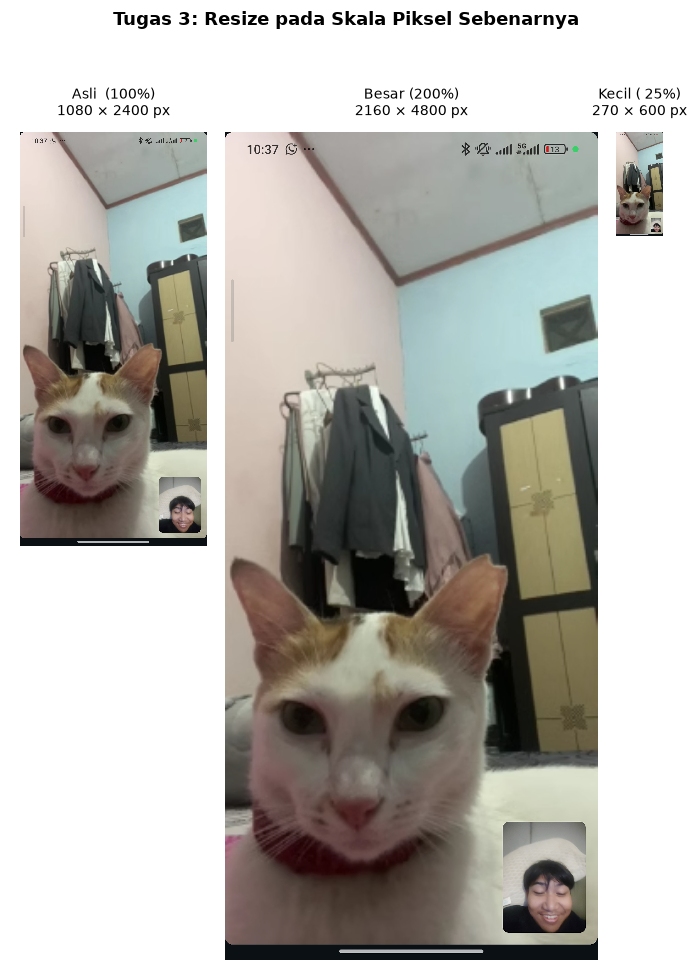

In [13]:
# ketiganya digambar pada SATU axes dengan koordinat piksel sebenarnya,
# sehingga perbedaan ukurannya benar-benar sebanding
H = ukuran_besar[1]
jarak = int(lebar * 0.10)

fig, ax = plt.subplots(figsize=(8, 9))
x_kiri = 0
for nama, arr in tabel:
    h, w = arr.shape[:2]
    ax.imshow(arr, extent=[x_kiri, x_kiri + w, h, 0])
    ax.text(x_kiri + w / 2, -H * 0.015, f"{nama}\n{w} × {h} px",
            ha="center", va="bottom", fontsize=9)
    x_kiri += w + jarak

ax.set_xlim(-jarak * 0.5, x_kiri)
ax.set_ylim(H * 1.01, -H * 0.10)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Tugas 3: Resize pada Skala Piksel Sebenarnya",
             fontsize=12, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()

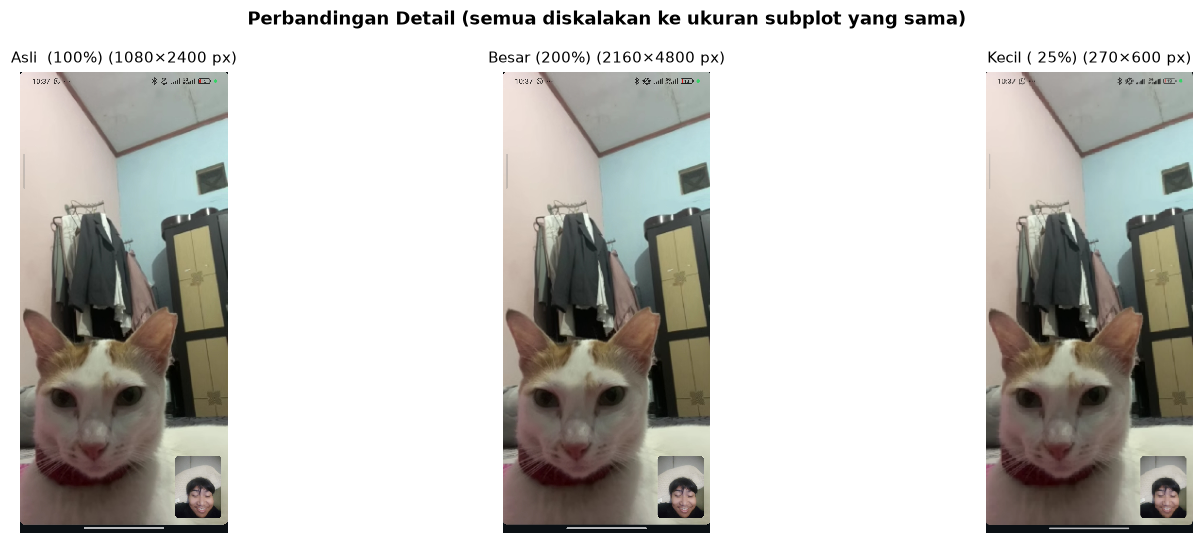

In [14]:
# versi kedua: tiap citra dipenuhkan ke subplot-nya masing-masing,
# supaya perbedaan DETAIL (bukan ukuran) yang terlihat
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, (nama, arr) in zip(ax, tabel):
    h, w = arr.shape[:2]
    a.imshow(arr)
    a.set_title(f"{nama} ({w}×{h} px)", fontsize=10)
    a.axis("off")
plt.suptitle("Perbandingan Detail (semua diskalakan ke ukuran subplot yang sama)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Bukti kehilangan detail

Kalau versi 25% dikembalikan lagi ke ukuran asli, detail yang sudah terbuang
**tidak bisa dipulihkan**. Kita zoom satu potongan kecil untuk melihatnya.

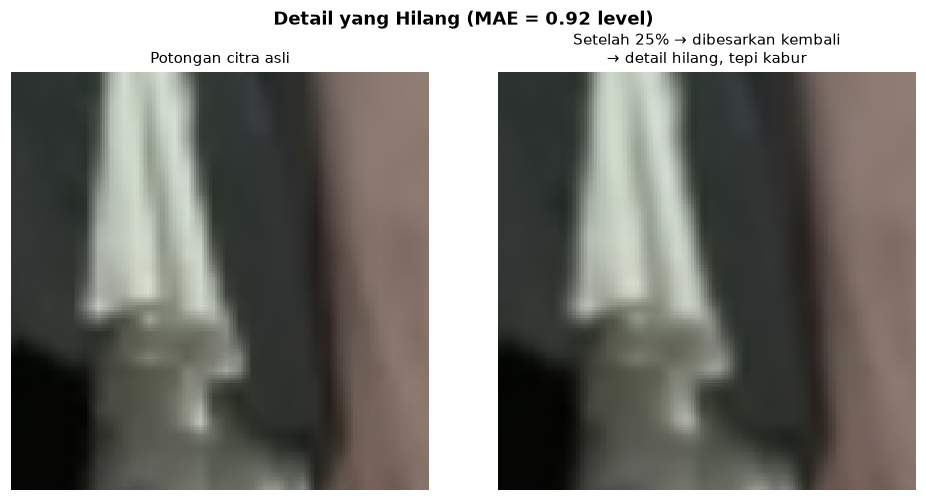

In [15]:
# kembalikan versi 25% ke ukuran asli
img_kecil_balik = cv2.resize(img_kecil, (lebar, tinggi), interpolation=cv2.INTER_CUBIC)

# ambil potongan 160x160 px dari tengah citra
sisi = min(160, lebar // 2, tinggi // 2)
cy, cx = tinggi // 2, lebar // 2
ys, xs = slice(cy - sisi // 2, cy + sisi // 2), slice(cx - sisi // 2, cx + sisi // 2)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.6))
ax[0].imshow(img_rgb[ys, xs]);          ax[0].set_title("Potongan citra asli", fontsize=10)
ax[1].imshow(img_kecil_balik[ys, xs]);  ax[1].set_title("Setelah 25% → dibesarkan kembali\n→ detail hilang, tepi kabur", fontsize=10)
for a in ax:
    a.axis("off")

mae_hilang = np.abs(img_rgb.astype(float) - img_kecil_balik.astype(float)).mean()
plt.suptitle(f"Detail yang Hilang (MAE = {mae_hilang:.2f} level)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
# simpan hasil resize (ingat: cv2.imwrite butuh urutan BGR)
cv2.imwrite(os.path.join(OUTPUT_DIR, "resize_200persen.jpg"),
            cv2.cvtColor(img_besar, cv2.COLOR_RGB2BGR))
cv2.imwrite(os.path.join(OUTPUT_DIR, "resize_25persen.jpg"),
            cv2.cvtColor(img_kecil, cv2.COLOR_RGB2BGR))
print("Tersimpan: output/resize_200persen.jpg, output/resize_25persen.jpg")

Tersimpan: output/resize_200persen.jpg, output/resize_25persen.jpg


---
## Tugas 4: Crop Objek Utama

Crop pada NumPy hanyalah *array slicing*: `citra[y1:y2, x1:x2]`. Perhatikan
urutannya: **baris (y) dulu, baru kolom (x)**, kebalikan dari notasi koordinat
kartesius yang biasa.

Koordinat di bawah ditulis dalam **rasio (0.0-1.0)** terhadap ukuran citra,
supaya nilainya tetap valid berapa pun resolusi foto yang dipakai.

> Nilai `ROI` di bawah sudah disetel untuk foto pada folder `images/` (wajah
> kucing). Jika fotonya diganti, sesuaikan nilainya lalu jalankan sel
> pratinjau untuk mengecek posisi kotak sebelum di-crop.

In [17]:
# ROI = Region of Interest, dalam rasio terhadap lebar/tinggi citra
# format: (x1, y1, x2, y2) dengan nilai 0.0 - 1.0
ROI = (0.00, 0.49, 0.74, 0.93)   # <-- ubah sesuai posisi objek utama

x1 = int(ROI[0] * lebar)
y1 = int(ROI[1] * tinggi)
x2 = int(ROI[2] * lebar)
y2 = int(ROI[3] * tinggi)

# jaga-jaga supaya koordinat tidak keluar batas / terbalik
x1, x2 = sorted((max(0, x1), min(lebar,  x2)))
y1, y2 = sorted((max(0, y1), min(tinggi, y2)))
if x2 - x1 < 1 or y2 - y1 < 1:
    raise ValueError("ROI terlalu kecil, periksa kembali nilai rasionya.")

print(f"Koordinat piksel : ({x1}, {y1}) -> ({x2}, {y2})")
print(f"Ukuran crop      : {x2-x1} x {y2-y1} px")
print(f"Porsi dari asli  : {(x2-x1)*(y2-y1) / (lebar*tinggi) * 100:.1f}% area")

Koordinat piksel : (0, 1176) -> (799, 2232)
Ukuran crop      : 799 x 1056 px
Porsi dari asli  : 32.6% area


### Pratinjau kotak crop

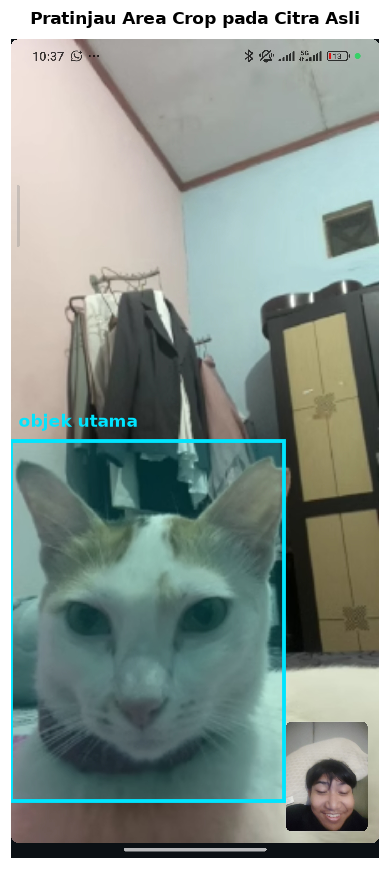

In [18]:
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(img_rgb)
ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                       linewidth=2.5, edgecolor="#00e5ff",
                       facecolor="#00e5ff", alpha=0.18))
ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                       linewidth=2.5, edgecolor="#00e5ff", facecolor="none"))
# offset proporsional terhadap ukuran citra, bukan piksel tetap,
# supaya label tidak menempel di garis pada citra beresolusi tinggi
ax.text(x1 + lebar * 0.02, y1 - tinggi * 0.012, "objek utama", va="bottom", color="#00e5ff",
        fontsize=11, fontweight="bold")
ax.set_title("Pratinjau Area Crop pada Citra Asli", fontsize=11,
             fontweight="bold", pad=10)
ax.axis("off")
plt.tight_layout()
plt.show()

### Hasil crop

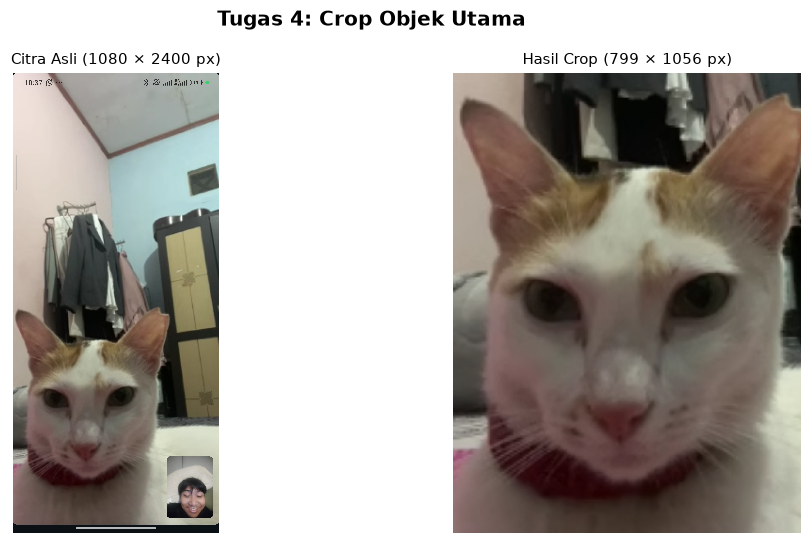

In [19]:
# crop = slicing NumPy, urutan [baris, kolom] = [y, x]
crop_rgb = img_rgb[y1:y2, x1:x2]

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(img_rgb)
ax[0].set_title(f"Citra Asli ({lebar} × {tinggi} px)", fontsize=10)
ax[1].imshow(crop_rgb)
ax[1].set_title(f"Hasil Crop ({crop_rgb.shape[1]} × {crop_rgb.shape[0]} px)", fontsize=10)
for a in ax:
    a.axis("off")
plt.suptitle("Tugas 4: Crop Objek Utama", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [20]:
# simpan hasil crop sebagai file baru
path_crop = os.path.join(OUTPUT_DIR, "crop_objek_utama.jpg")
cv2.imwrite(path_crop, cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2BGR),
            [cv2.IMWRITE_JPEG_QUALITY, 95])

ukuran_kb = os.path.getsize(path_crop) / 1024
print(f"Tersimpan  : {path_crop}")
print(f"Ukuran file: {ukuran_kb:.1f} KB")

# verifikasi dengan membaca ulang file yang barusan ditulis
cek = cv2.imread(path_crop)
print(f"Verifikasi : file terbaca, dimensi {cek.shape[1]} x {cek.shape[0]} px")

Tersimpan  : output/crop_objek_utama.jpg
Ukuran file: 104.7 KB
Verifikasi : file terbaca, dimensi 799 x 1056 px


---
## Ringkasan

| Tugas | Yang dikerjakan | Berkas keluaran |
|-------|-----------------|-----------------|
| 1 | Menampilkan citra dengan Matplotlib, membandingkan array BGR mentah vs RGB hasil konversi, plus dekomposisi kanal & histogram | - |
| 2 | Grayscale manual (BT.601 & rata-rata) vs `cv2.cvtColor` dan `PIL.convert('L')`, dibandingkan lewat MAE / PSNR / peta selisih | `grayscale_manual.jpg`, `grayscale_bawaan.jpg` |
| 3 | Resize 200% (`INTER_CUBIC`) dan 25% (`INTER_AREA`), subplot berdampingan pada skala piksel sebenarnya | `resize_200persen.jpg`, `resize_25persen.jpg` |
| 4 | Crop objek utama via NumPy slicing dengan ROI berbasis rasio, disimpan sebagai file baru | `crop_objek_utama.jpg` |

### Catatan penting

* **BGR vs RGB**: OpenCV memakai BGR, hampir semua library lain memakai RGB.
  Lupa mengonversi adalah sumber bug warna paling umum di pemrosesan citra.
* **Bobot grayscale**: BT.601 (0.299 / 0.587 / 0.114) mencerminkan sensitivitas
  mata manusia; rata-rata sederhana tidak, dan hasilnya terlihat lebih datar.
* **Pilihan interpolasi**: `INTER_AREA` untuk memperkecil, `INTER_CUBIC` atau
  `INTER_LANCZOS4` untuk memperbesar.
* **Slicing untuk crop**: urutannya `[y1:y2, x1:x2]`, baris dulu baru kolom.

In [21]:
# daftar seluruh berkas keluaran
print("Isi folder output/:\n")
for f in sorted(os.listdir(OUTPUT_DIR)):
    p = os.path.join(OUTPUT_DIR, f)
    print(f"  {f:<28} {os.path.getsize(p)/1024:>8.1f} KB")

Isi folder output/:

  .gitkeep                          0.0 KB
  crop_objek_utama.jpg            104.7 KB
  grayscale_bawaan.jpg            253.4 KB
  grayscale_manual.jpg            266.9 KB
  resize_200persen.jpg            868.9 KB
  resize_25persen.jpg              39.5 KB
